In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

cluster_summary = pd.read_csv("/content/drive/MyDrive/gridlock_flipkart/cluster_summary_updated.csv")
hourly = pd.read_csv("/content/drive/MyDrive/gridlock_flipkart/cluster_hourly_distribution.csv")

hour_cols = [f"hour_{h}" for h in range(24)]
hour_pivot = hourly.set_index("cluster_id")[hour_cols]
hour_pivot.columns = range(24)

print(f"Clusters: {len(hour_pivot)}")
hour_pivot.head()

Clusters: 30


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cluster_id,,,,,,,,,,,,,,,,,,,,,
0,147.0,71.0,175.0,119.0,137.0,143.0,175.0,167.0,112.0,66.0,...,0.0,0.0,0.0,0.0,2.0,196.0,154.0,163.0,200.0,388.0
1,118.0,64.0,76.0,137.0,166.0,400.0,329.0,174.0,122.0,9.0,...,0.0,0.0,0.0,0.0,0.0,24.0,94.0,126.0,133.0,121.0
2,112.0,208.0,180.0,116.0,145.0,114.0,45.0,10.0,11.0,9.0,...,0.0,0.0,0.0,0.0,0.0,25.0,56.0,153.0,158.0,345.0
3,30.0,30.0,122.0,95.0,114.0,215.0,141.0,93.0,54.0,12.0,...,2.0,2.0,1.0,21.0,142.0,311.0,237.0,52.0,60.0,51.0
4,109.0,205.0,174.0,138.0,235.0,181.0,167.0,80.0,53.0,36.0,...,0.0,0.0,0.0,0.0,6.0,146.0,156.0,177.0,114.0,72.0


## 1. Enforcement coverage score

Fraction of the 24-hour day where a cluster has *any* recorded violation.
Low score = large unmonitored time window for that zone.

```
enforcement_coverage_score = (hours with >= 1 violation) / 24
```


In [3]:
enforcement_coverage = (hour_pivot > 0).sum(axis=1) / 24

cluster_summary = cluster_summary.merge(
    enforcement_coverage.reset_index().rename(columns={0: "enforcement_coverage_score"}),
    on="cluster_id", how="left"
)

cluster_summary[["cluster_id", "enforcement_coverage_score"]]\
    .sort_values("enforcement_coverage_score")

,cluster_id,enforcement_coverage_score
11,16,0.583333
12,23,0.583333
8,6,0.583333
26,14,0.583333
29,17,0.583333
24,18,0.583333
21,28,0.625000
10,15,0.625000
28,10,0.625000
25,2,0.666667


## 2. Identify each cluster's gap window

For each cluster, find the longest consecutive run of zero-violation hours,
and the start/end hour of that run. This is needed to look at the hours
bordering the gap in the next step.


In [4]:
def longest_zero_run_with_bounds(row):
    vals = row.values
    max_run = 0
    current = 0
    start_idx = None
    best_start, best_end = None, None
    for i, v in enumerate(vals):
        if v == 0:
            if current == 0:
                start_idx = i
            current += 1
            if current > max_run:
                max_run = current
                best_start, best_end = start_idx, i
        else:
            current = 0
    return pd.Series({
        "gap_length_hours": max_run,
        "gap_start_hour": best_start,
        "gap_end_hour": best_end
    })

gap_info = hour_pivot.apply(longest_zero_run_with_bounds, axis=1)
cluster_summary = cluster_summary.merge(gap_info.reset_index(), on="cluster_id", how="left")

cluster_summary[["cluster_id","enforcement_coverage_score",
                 "gap_length_hours","gap_start_hour","gap_end_hour"]]\
    .sort_values("gap_length_hours", ascending=False)

,cluster_id,enforcement_coverage_score,gap_length_hours,gap_start_hour,gap_end_hour
11,16,0.583333,10,9,18
8,6,0.583333,10,9,18
12,23,0.583333,10,11,20
29,17,0.583333,10,10,19
24,18,0.583333,10,9,18
21,28,0.625000,9,10,18
26,14,0.583333,9,10,18
5,20,0.666667,8,10,17
28,10,0.625000,8,12,19
25,2,0.666667,8,11,18


## 3. Bordering-hour severity — the blind spot signal

For each cluster's gap window, look at the 2 hours immediately before the gap
starts and the 2 hours immediately after it ends. If those bordering hours
still show meaningful violation activity, it's evidence the gap is hiding
real violations rather than reflecting genuine zone inactivity.


In [5]:
def get_bordering_hours(row, hour_pivot_row):
    start, end = int(row["gap_start_hour"]), int(row["gap_end_hour"])
    before_hours = [(start - 1 - i) % 24 for i in range(2)]
    after_hours  = [(end + 1 + i) % 24 for i in range(2)]
    border_hours = before_hours + after_hours
    border_counts = hour_pivot_row[border_hours]
    return border_counts.sum(), border_counts.mean()

border_totals = []
border_avgs   = []

for cid in cluster_summary["cluster_id"]:
    row = cluster_summary[cluster_summary["cluster_id"] == cid].iloc[0]
    if pd.isna(row["gap_start_hour"]):
        border_totals.append(0)
        border_avgs.append(0)
        continue
    total, avg = get_bordering_hours(row, hour_pivot.loc[cid])
    border_totals.append(total)
    border_avgs.append(avg)

cluster_summary["border_hours_violation_total"] = border_totals
cluster_summary["border_hours_violation_avg"]   = border_avgs

cluster_summary[["cluster_id","gap_length_hours",
                 "border_hours_violation_total","border_hours_violation_avg"]]\
    .sort_values("border_hours_violation_avg", ascending=False)

,cluster_id,gap_length_hours,border_hours_violation_total,border_hours_violation_avg
21,28,9,768.0,192.00
29,17,10,449.0,112.25
11,16,10,317.0,79.25
24,18,10,276.0,69.00
22,12,6,226.0,56.50
13,0,6,208.0,52.00
2,25,6,188.0,47.00
28,10,8,183.0,45.75
10,15,6,170.0,42.50
18,4,6,168.0,42.00


## 4. Blind spot risk score

Combines low enforcement coverage with high bordering-hour activity into a
single score: zones where the gap is long AND the hours around it are still
busy get flagged as likely hiding unmonitored violations.

```
blind_spot_risk = normalized(border_hours_violation_avg) * (1 - enforcement_coverage_score)
```


In [6]:
# Normalize border activity 0-1 across clusters for comparability
max_border = cluster_summary["border_hours_violation_avg"].max()
cluster_summary["border_activity_norm"] = (
    cluster_summary["border_hours_violation_avg"] / max_border
    if max_border > 0 else 0
)

cluster_summary["blind_spot_risk"] = (
    cluster_summary["border_activity_norm"]
    * (1 - cluster_summary["enforcement_coverage_score"])
)

cluster_summary[["cluster_id","top_station","enforcement_coverage_score",
                 "border_activity_norm","blind_spot_risk"]]\
    .sort_values("blind_spot_risk", ascending=False)

,cluster_id,top_station,enforcement_coverage_score,border_activity_norm,blind_spot_risk
21,28,Upparpet,0.625000,1.000000,0.375000
29,17,Pulikeshinagar(F.Town),0.583333,0.584635,0.243598
11,16,Vijayanagara,0.583333,0.412760,0.171984
24,18,Rajajinagar,0.583333,0.359375,0.149740
28,10,Basavanagudi,0.625000,0.238281,0.089355
10,15,Vijayanagara,0.625000,0.221354,0.083008
26,14,High ground,0.583333,0.191406,0.079753
22,12,Byatarayanapura,0.750000,0.294271,0.073568
12,23,Shivajinagar,0.583333,0.166667,0.069444
13,0,Chikkajala,0.750000,0.270833,0.067708


## 5. Coverage-corrected Time Risk

Replace the raw night-concentration-driven `time_risk` (from Stage 3) with a
version that discounts clusters whose apparent "predictability" comes from
enforcement absence rather than genuine violation concentration.

```
time_risk_corrected = time_risk * enforcement_coverage_score + blind_spot_risk * (1 - enforcement_coverage_score)
```

This keeps high time_risk meaningful for well-covered zones, while surfacing
poorly-covered zones through the blind_spot_risk term instead of letting them
masquerade as "predictable" purely because most of their day is unmonitored.


In [7]:
cluster_summary["time_risk_corrected"] = (
    cluster_summary["time_risk"] * cluster_summary["enforcement_coverage_score"]
    + cluster_summary["blind_spot_risk"] * (1 - cluster_summary["enforcement_coverage_score"])
)

compare = cluster_summary[["cluster_id","top_station","time_risk",
                           "enforcement_coverage_score","blind_spot_risk",
                           "time_risk_corrected"]]\
    .sort_values("time_risk_corrected", ascending=False)
compare

,cluster_id,top_station,time_risk,enforcement_coverage_score,blind_spot_risk,time_risk_corrected
21,28,Upparpet,0.350689,0.625000,0.375000,0.359805
29,17,Pulikeshinagar(F.Town),0.355097,0.583333,0.243598,0.308639
26,14,High ground,0.407344,0.583333,0.079753,0.270848
6,24,Shivajinagar,0.390556,0.666667,0.003906,0.261673
23,3,K.R. Pura,0.283876,0.916667,0.007595,0.260853
12,23,Shivajinagar,0.374828,0.583333,0.069444,0.247585
24,18,Rajajinagar,0.299936,0.583333,0.149740,0.237354
5,20,Malleshwaram,0.327516,0.666667,0.049479,0.234837
17,1,Kodigehalli,0.298884,0.750000,0.040039,0.234173
10,15,Vijayanagara,0.322737,0.625000,0.083008,0.232839


## 6. Two output lists — the actual deliverable of this stage

The problem statement asks for *targeted* enforcement, not just "go where
violations already are." This stage produces two distinct, actionable lists:

1. **High-impact, well-covered zones** — keep current night patrol, it's working
2. **High blind-spot-risk zones** — recommend daytime patrol reallocation,
   since these zones show real violation activity but are barely monitored
   during the day


In [8]:
print("="*65)
print("LIST 1 — HIGH IMPACT, WELL-COVERED ZONES (maintain current patrol)")
print("="*65)
list1 = cluster_summary[cluster_summary["enforcement_coverage_score"] >= 0.7]\
    .sort_values("size", ascending=False)
print(list1[["cluster_id","top_station","size","enforcement_coverage_score"]]\
      .head(10).to_string(index=False))

print("\n" + "="*65)
print("LIST 2 — HIGH BLIND-SPOT-RISK ZONES (recommend daytime reallocation)")
print("="*65)
list2 = cluster_summary.sort_values("blind_spot_risk", ascending=False)
print(list2[["cluster_id","top_station","size","gap_length_hours",
            "enforcement_coverage_score","blind_spot_risk"]]\
      .head(10).to_string(index=False))

LIST 1 — HIGH IMPACT, WELL-COVERED ZONES (maintain current patrol)
 cluster_id       top_station  size  enforcement_coverage_score
         29          Upparpet  8292                    0.750000
          7        HSR Layout  5264                    0.875000
         25       City Market  4879                    0.750000
         11      Malleshwaram  4338                    0.708333
         27          Upparpet  4087                    0.750000
         21      Malleshwaram  3436                    0.708333
          9 Jeevanbheemanagar  3311                    0.875000
          0        Chikkajala  2425                    0.750000
         19           Halasur  2374                    0.750000
         22      Shivajinagar  2252                    0.833333

LIST 2 — HIGH BLIND-SPOT-RISK ZONES (recommend daytime reallocation)
 cluster_id            top_station  size  gap_length_hours  enforcement_coverage_score  blind_spot_risk
         28               Upparpet  1972               

## 7. Visual comparison — coverage vs blind spot risk

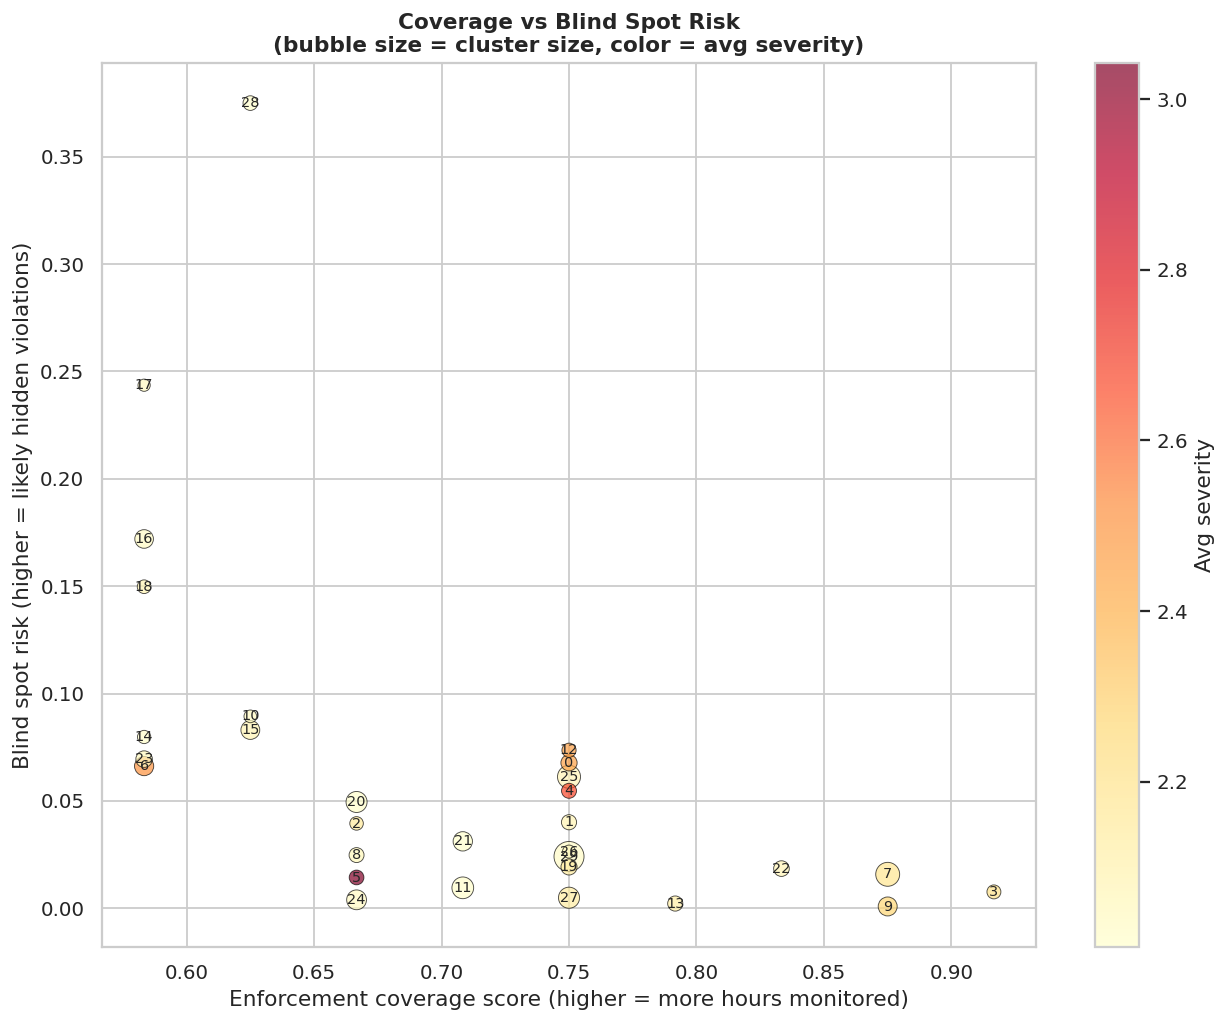

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    cluster_summary["enforcement_coverage_score"],
    cluster_summary["blind_spot_risk"],
    s=cluster_summary["size"] / 30,
    c=cluster_summary["avg_severity"],
    cmap="YlOrRd",
    alpha=0.7,
    edgecolors="black",
    linewidths=0.5
)

for _, row in cluster_summary.iterrows():
    ax.annotate(str(int(row["cluster_id"])),
                (row["enforcement_coverage_score"], row["blind_spot_risk"]),
                fontsize=8, ha="center", va="center")

ax.set_xlabel("Enforcement coverage score (higher = more hours monitored)")
ax.set_ylabel("Blind spot risk (higher = likely hidden violations)")
ax.set_title("Coverage vs Blind Spot Risk\n"
             "(bubble size = cluster size, color = avg severity)",
             fontweight="bold")
plt.colorbar(scatter, label="Avg severity")
plt.tight_layout()
plt.savefig("s3b_coverage_vs_blindspot.png")
plt.show()